# Figure 8: Cross-Region Binding During Binocular Rivalry

**Paper Figure 8** — Occipital-parietal topological binding changes during perceptual switches.

**Motivation**: Figure 7 showed that single-channel (Oz) persistent homology detects
topological transitions aligned with perceptual switches. Here we test a stronger
hypothesis: does the *inter-region coupling* between occipital and parietal cortex
change during perceptual transitions?

**Method**: The `BindingDetector` computes persistence images for:
- **Joint embedding** (Oz + Pz concatenated delay vectors)
- **Marginal embeddings** (Oz alone, Pz alone)

The binding score = L1 norm of the positive residual (joint - max(marginals)).
Higher scores indicate emergent topology in the joint space that is absent from
either marginal alone — i.e., genuine inter-region coupling.

**Pipeline**:
1. Load rivalry epoch, extract Oz (occipital) and Pz (parietal) channels
2. Bandpass filter to theta-alpha (4-13 Hz)
3. Compute full-epoch binding as a baseline
4. Sliding-window binding (10s windows, 5s steps) to get a time course
5. Compare binding scores near transition windows vs stable windows
6. Statistical test: are transition-window binding scores significantly different?

**Dataset**: Subject 1, Nie/Katyal/Engel (2023), DOI: [10.13020/9sy5-a716](https://doi.org/10.13020/9sy5-a716)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import scipy.io
from scipy.signal import butter, sosfilt
from scipy.stats import mannwhitneyu
from pathlib import Path
import time
import warnings

from att.config import set_seed
from att.neuro.embedding import embed_channel
from att.embedding.takens import TakensEmbedder
from att.embedding.joint import JointEmbedder
from att.binding import BindingDetector

rcParams['figure.dpi'] = 150
rcParams['savefig.dpi'] = 300
rcParams['font.size'] = 11
rcParams['font.family'] = 'serif'

set_seed(42)

DATA_DIR = Path("../data/eeg/rivalry_ssvep/Sucharit - 012516_3629")
print("Setup complete.")

Setup complete.


## 1. Load EEG Data and Behavioral Switches

Load epoch 0 from the rivalry condition. Extract channel locations and behavioral
switch times from button-press reports.

In [2]:
# Load rivalry EEG epochs
eeg_file = DATA_DIR / "Epochs" / "csd_rejevs_icacomprem_gaprem_filt_rivindiff_riv_12.mat"
eeg = scipy.io.loadmat(str(eeg_file), simplify_cells=True)

ch_names = [ch['labels'] for ch in eeg['chanlocs']]
sfreq = int(eeg['fs'])
epoch_data = eeg['epochs'][0]  # First rivalry epoch

print(f"Channels ({len(ch_names)}): {ch_names}")
print(f"Sampling rate: {sfreq} Hz")
print(f"Epoch 0 shape: {epoch_data.shape} ({epoch_data.shape[1]/sfreq:.1f}s)")

# Load behavioral data
beh_file = DATA_DIR / "Behavior" / "BR_Rivalry_3629_250116.mat"
beh = scipy.io.loadmat(str(beh_file), simplify_cells=True)
results_beh = beh['results']

# paramSet=2 sessions correspond to riv_12.mat epochs
paramset2_indices = [i for i, r in enumerate(results_beh) if r['params']['paramSet'] == 2]
r = results_beh[paramset2_indices[0]]
psycho = r['psycho']
tKeyPress = psycho['tKeyPress']
responseKey = psycho['responseKey']

# Extract perceptual switches
switches = []
for i in range(1, len(responseKey)):
    if responseKey[i] != responseKey[i-1]:
        switches.append({
            'time': tKeyPress[i],
            'from_key': int(responseKey[i-1]),
            'to_key': int(responseKey[i]),
        })

switch_times = np.array([s['time'] for s in switches])
print(f"\nBehavioral switches: {len(switches)}")
print(f"Switch times (s): {[f'{t:.1f}' for t in switch_times]}")

# Known changepoint times from fig7 TransitionDetector (for reference)
changepoint_times = np.array([42.1, 50.4, 69.9, 79.3, 94.9, 102.6, 109.9])
print(f"Fig7 changepoints (s): {changepoint_times}")

Channels (34): ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'T7', 'C3', 'Cz', 'C4', 'T8', 'CP5', 'CP1', 'CP2', 'CP6', 'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2', 'PO3', 'PO4', 'PO7', 'PO8']
Sampling rate: 360 Hz
Epoch 0 shape: (34, 43196) (120.0s)

Behavioral switches: 41
Switch times (s): ['8.6', '10.4', '12.5', '14.3', '16.6', '23.6', '30.9', '33.5', '42.9', '44.5', '47.5', '49.0', '51.1', '52.7', '56.9', '60.1', '61.6', '63.5', '65.0', '66.7', '69.3', '70.0', '71.8', '75.3', '77.1', '78.5', '79.8', '82.0', '83.7', '85.7', '87.9', '89.6', '91.7', '96.9', '99.8', '103.3', '105.9', '107.8', '113.6', '114.5', '117.4']
Fig7 changepoints (s): [ 42.1  50.4  69.9  79.3  94.9 102.6 109.9]


## 2. Extract and Filter Oz (Occipital) and Pz (Parietal) Channels

Apply 4th-order Butterworth bandpass (4-13 Hz, theta-alpha) to both channels.
This band captures the dominant rivalry-related oscillatory dynamics.

Oz (index 28): raw std=40.74, filtered std=13.20
Pz (index 23): raw std=44.60, filtered std=11.78
Duration: 120.0s (43196 samples)


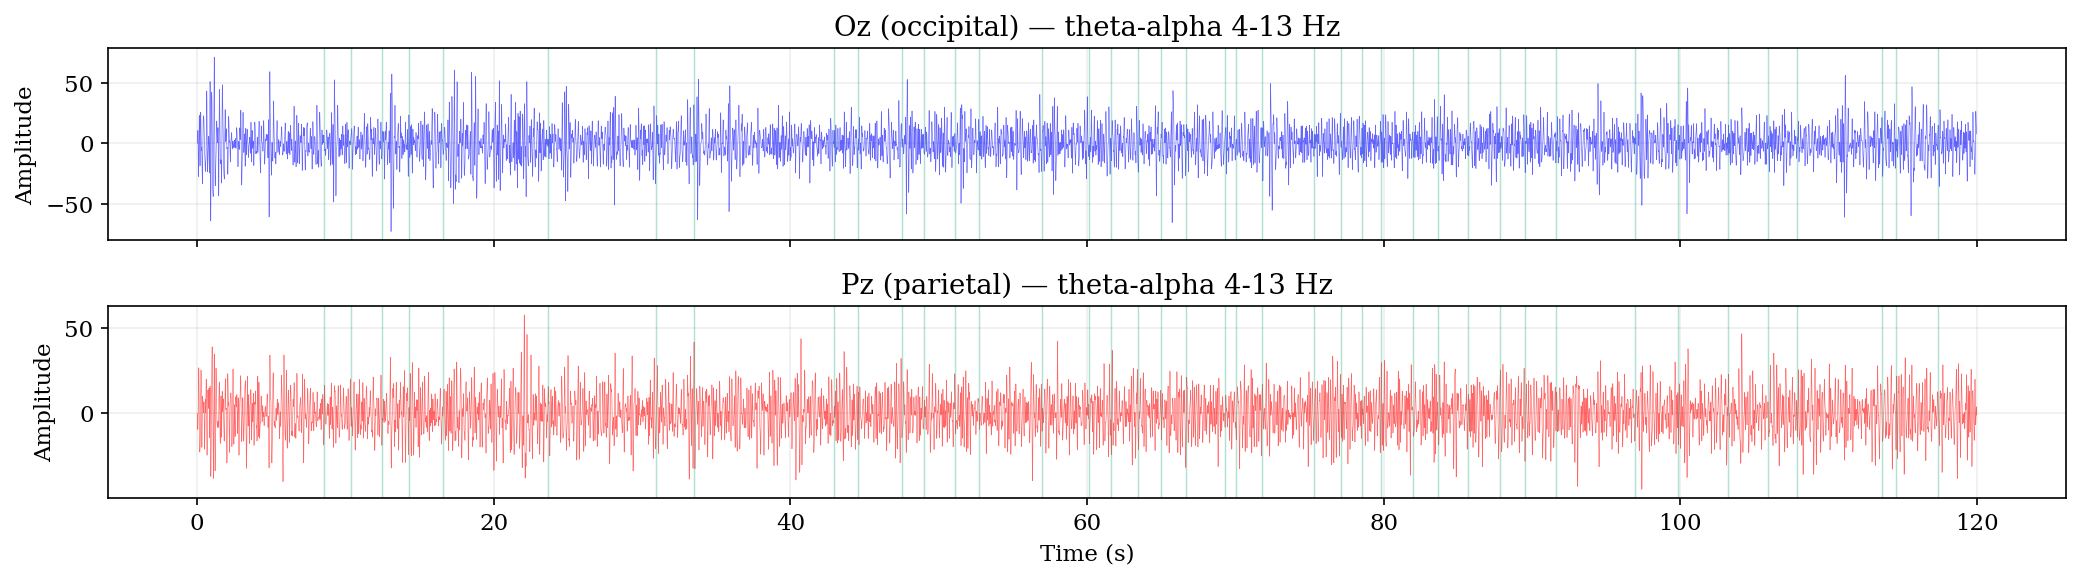

In [3]:
# Extract channels
oz_idx = ch_names.index('Oz')
pz_idx = ch_names.index('Pz')
signal_oz_raw = epoch_data[oz_idx].astype(np.float64)
signal_pz_raw = epoch_data[pz_idx].astype(np.float64)

# Theta-alpha bandpass filter (4-13 Hz)
sos = butter(4, [4, 13], btype='bandpass', fs=sfreq, output='sos')
signal_oz = sosfilt(sos, signal_oz_raw)
signal_pz = sosfilt(sos, signal_pz_raw)

t_full = np.arange(len(signal_oz)) / sfreq
duration = len(signal_oz) / sfreq

print(f"Oz (index {oz_idx}): raw std={signal_oz_raw.std():.2f}, filtered std={signal_oz.std():.2f}")
print(f"Pz (index {pz_idx}): raw std={signal_pz_raw.std():.2f}, filtered std={signal_pz.std():.2f}")
print(f"Duration: {duration:.1f}s ({len(signal_oz)} samples)")

# Quick visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 4), sharex=True)
axes[0].plot(t_full, signal_oz, 'b-', linewidth=0.3, alpha=0.6)
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Oz (occipital) — theta-alpha 4-13 Hz')
axes[0].grid(True, alpha=0.2)

axes[1].plot(t_full, signal_pz, 'r-', linewidth=0.3, alpha=0.6)
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Pz (parietal) — theta-alpha 4-13 Hz')
axes[1].grid(True, alpha=0.2)

for ax in axes:
    for sw in switches:
        ax.axvline(sw['time'], color='#009E73', alpha=0.3, linewidth=0.7)

plt.tight_layout()
plt.show()

## 3. Embedding Parameter Estimation

Estimate Takens embedding parameters for each channel independently using
`embed_channel()` (auto with fallback). Then select **shared parameters** for
the sliding-window analysis so that marginal and joint embeddings are directly
comparable across all windows.

We use the same delay and dimension for both channels. This ensures the joint
embedding has dimension = 2 * dim_marginal, and that binding scores are not
confounded by dimensionality differences between marginals.

In [4]:
# Auto-estimate on full signal to determine good shared parameters
cloud_oz_full, meta_oz = embed_channel(signal_oz, band="theta_alpha", sfreq=sfreq)
cloud_pz_full, meta_pz = embed_channel(signal_pz, band="theta_alpha", sfreq=sfreq)

print("Full-signal embedding estimation:")
print(f"  Oz: method={meta_oz['method']}, delay={meta_oz['delay']}, "
      f"dim={meta_oz['dimension']}, cond={meta_oz['condition_number']:.2f}")
print(f"  Pz: method={meta_pz['method']}, delay={meta_pz['delay']}, "
      f"dim={meta_pz['dimension']}, cond={meta_pz['condition_number']:.2f}")

# Select shared parameters: average delay, minimum dimension for comparability
SHARED_DELAY = round((meta_oz['delay'] + meta_pz['delay']) / 2)
SHARED_DIM = min(meta_oz['dimension'], meta_pz['dimension'])
# Cap dimension at 5 for computational efficiency in sliding windows
SHARED_DIM = min(SHARED_DIM, 5)

print("\nShared parameters for sliding-window analysis:")
print(f"  delay = {SHARED_DELAY} samples ({SHARED_DELAY/sfreq*1000:.1f} ms)")
print(f"  dimension = {SHARED_DIM}")
print(f"  Joint embedding dimension = {2 * SHARED_DIM}")
print(f"  Marginal cloud points per 10s window: ~{int(10*sfreq) - (SHARED_DIM-1)*SHARED_DELAY}")

Full-signal embedding estimation:
  Oz: method=auto, delay=12, dim=6, cond=3.56
  Pz: method=auto, delay=13, dim=6, cond=4.22

Shared parameters for sliding-window analysis:
  delay = 12 samples (33.3 ms)
  dimension = 5
  Joint embedding dimension = 10
  Marginal cloud points per 10s window: ~3552


## 4. Full-Epoch Binding (Baseline)

Compute binding on the entire ~120s epoch to establish a global baseline.
This tells us whether there is any significant occipital-parietal coupling
overall during binocular rivalry.

In [5]:
# Full-epoch binding with shared embedding parameters
emb_x = TakensEmbedder(delay=SHARED_DELAY, dimension=SHARED_DIM)
emb_y = TakensEmbedder(delay=SHARED_DELAY, dimension=SHARED_DIM)
joint_emb = JointEmbedder(
    delays=[SHARED_DELAY, SHARED_DELAY],
    dimensions=[SHARED_DIM, SHARED_DIM],
)

bd_full = BindingDetector(max_dim=1, baseline="max")
t0 = time.time()
bd_full.fit(
    signal_oz, signal_pz,
    marginal_embedder_x=emb_x,
    marginal_embedder_y=emb_y,
    joint_embedder=joint_emb,
    subsample=500,
    seed=42,
)
elapsed = time.time() - t0

full_score = bd_full.binding_score()
full_features = bd_full.binding_features()
full_eq = bd_full.embedding_quality()

print(f"Full-epoch binding computation: {elapsed:.1f}s")
print(f"Binding score: {full_score:.4f}")
print(f"Embedding quality: any_degenerate={full_eq['any_degenerate']}")
print("\nPer-dimension breakdown:")
for dim, feat in full_features.items():
    print(f"  H{dim}: n_excess={feat['n_excess']}, "
          f"total={feat['total_persistence']:.4f}, "
          f"max={feat['max_persistence']:.4f}")

Full-epoch binding computation: 0.4s
Binding score: 12.5340
Embedding quality: any_degenerate=False

Per-dimension breakdown:
  H0: n_excess=20, total=9.4975, max=1.8361
  H1: n_excess=47, total=3.0365, max=0.4098


## 5. Sliding-Window Binding Time Course

Compute binding in overlapping windows across the full epoch:
- **Window size**: 10 seconds (3600 samples) — long enough for reliable PH
- **Step size**: 5 seconds (1800 samples) — 50% overlap for smooth time course
- **Subsample**: 400 points per cloud for Ripser efficiency

Each window produces a binding score measuring occipital-parietal coupling
strength at that time point.

In [6]:
WINDOW_SEC = 10
STEP_SEC = 5
SUBSAMPLE = 400

window_samples = int(WINDOW_SEC * sfreq)
step_samples = int(STEP_SEC * sfreq)
n_samples = len(signal_oz)

# Generate window start positions
starts = list(range(0, n_samples - window_samples + 1, step_samples))
n_windows = len(starts)

print(f"Window: {WINDOW_SEC}s ({window_samples} samples)")
print(f"Step: {STEP_SEC}s ({step_samples} samples)")
print(f"Number of windows: {n_windows}")
print(f"Time range: 0 - {(starts[-1] + window_samples) / sfreq:.1f}s")

# Compute binding for each window
binding_scores = []
binding_features_list = []
window_centers_sec = []

t0_total = time.time()
for i, start in enumerate(starts):
    end = start + window_samples
    seg_oz = signal_oz[start:end]
    seg_pz = signal_pz[start:end]
    center_sec = (start + end) / 2 / sfreq
    window_centers_sec.append(center_sec)

    # Fresh embedders for each window (same shared params)
    emb_x = TakensEmbedder(delay=SHARED_DELAY, dimension=SHARED_DIM)
    emb_y = TakensEmbedder(delay=SHARED_DELAY, dimension=SHARED_DIM)
    joint_emb = JointEmbedder(
        delays=[SHARED_DELAY, SHARED_DELAY],
        dimensions=[SHARED_DIM, SHARED_DIM],
    )

    bd = BindingDetector(max_dim=1, baseline="max")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # Suppress degeneracy warnings for speed
        bd.fit(
            seg_oz, seg_pz,
            marginal_embedder_x=emb_x,
            marginal_embedder_y=emb_y,
            joint_embedder=joint_emb,
            subsample=SUBSAMPLE,
            seed=42,
        )

    score = bd.binding_score()
    features = bd.binding_features()
    binding_scores.append(score)
    binding_features_list.append(features)

    if (i + 1) % 5 == 0 or i == 0:
        elapsed = time.time() - t0_total
        eta = elapsed / (i + 1) * (n_windows - i - 1)
        print(f"  Window {i+1}/{n_windows}: center={center_sec:.1f}s, "
              f"score={score:.4f}, elapsed={elapsed:.1f}s, ETA={eta:.0f}s")

total_elapsed = time.time() - t0_total
binding_scores = np.array(binding_scores)
window_centers_sec = np.array(window_centers_sec)

print(f"\nDone in {total_elapsed:.1f}s ({total_elapsed/n_windows:.2f}s per window)")
print(f"Binding score range: [{binding_scores.min():.4f}, {binding_scores.max():.4f}]")
print(f"Binding score mean +/- std: {binding_scores.mean():.4f} +/- {binding_scores.std():.4f}")

Window: 10s (3600 samples)
Step: 5s (1800 samples)
Number of windows: 22
Time range: 0 - 115.0s


  Window 1/22: center=5.0s, score=6.6318, elapsed=0.3s, ETA=6s


  Window 5/22: center=25.0s, score=8.9992, elapsed=1.5s, ETA=5s


  Window 10/22: center=50.0s, score=12.0474, elapsed=2.9s, ETA=3s


  Window 15/22: center=75.0s, score=17.2315, elapsed=4.3s, ETA=2s


  Window 20/22: center=100.0s, score=12.6506, elapsed=5.9s, ETA=1s



Done in 6.4s (0.29s per window)
Binding score range: [5.0602, 34.1324]
Binding score mean +/- std: 14.1088 +/- 7.4278


## 6. Classify Windows by Switch Density

With 41 behavioral switches across 120s, every 10s window contains at least one
switch. Instead of a binary transition/stable split, we classify windows by
**switch density**: high-activity (above-median switch count) vs low-activity
(at or below median). We also test against the fig7 topological changepoints.

In [7]:
# Classify each window by switch count
is_changepoint = np.zeros(n_windows, dtype=bool)
n_switches_in_window = np.zeros(n_windows, dtype=int)

for i, start in enumerate(starts):
    win_start_sec = start / sfreq
    win_end_sec = (start + window_samples) / sfreq

    # Count behavioral switches in this window
    n_sw = np.sum((switch_times >= win_start_sec) & (switch_times <= win_end_sec))
    n_switches_in_window[i] = n_sw

    # Check for fig7 changepoints near this window (within 2s of window bounds)
    for cp_t in changepoint_times:
        if win_start_sec - 2 <= cp_t <= win_end_sec + 2:
            is_changepoint[i] = True
            break

# Median split on switch count
median_switches = np.median(n_switches_in_window)
is_high_activity = n_switches_in_window > median_switches
n_high = is_high_activity.sum()
n_low = (~is_high_activity).sum()

print(f"Switch counts per window: {n_switches_in_window}")
print(f"Median switch count: {median_switches}")
print(f"High-activity windows (>{median_switches:.0f} switches): {n_high}")
print(f"Low-activity windows (<={median_switches:.0f} switches): {n_low}")
print(f"Windows near fig7 changepoints: {is_changepoint.sum()}")

high_scores = binding_scores[is_high_activity]
low_scores = binding_scores[~is_high_activity]

print("\nBinding scores by switch density:")
print(f"  High-activity: mean={high_scores.mean():.4f} +/- {high_scores.std():.4f} (n={len(high_scores)})")
print(f"  Low-activity:  mean={low_scores.mean():.4f} +/- {low_scores.std():.4f} (n={len(low_scores)})")
print(f"  Ratio (high/low): {high_scores.mean() / low_scores.mean():.2f}x")

# Per-window detail
print("\nPer-window detail:")
for i in range(n_windows):
    label = "HIGH" if is_high_activity[i] else "low "
    cp_mark = " [CP]" if is_changepoint[i] else ""
    print(f"  {window_centers_sec[i]:6.1f}s: score={binding_scores[i]:7.4f}  "
          f"{label} (switches={n_switches_in_window[i]}){cp_mark}")

Switch counts per window: [1 4 4 2 1 2 2 2 4 4 3 5 6 4 6 6 5 4 3 3 3 4]
Median switch count: 4.0
High-activity windows (>4 switches): 5
Low-activity windows (<=4 switches): 17
Windows near fig7 changepoints: 14

Binding scores by switch density:
  High-activity: mean=24.5499 +/- 6.2073 (n=5)
  Low-activity:  mean=11.0379 +/- 4.3094 (n=17)
  Ratio (high/low): 2.22x

Per-window detail:
     5.0s: score= 6.6318  low  (switches=1)
    10.0s: score= 5.0602  low  (switches=4)
    15.0s: score= 6.1478  low  (switches=4)
    20.0s: score= 9.1892  low  (switches=2)
    25.0s: score= 8.9992  low  (switches=1)
    30.0s: score=11.0819  low  (switches=2)
    35.0s: score=11.3743  low  (switches=2)
    40.0s: score=10.5059  low  (switches=2) [CP]
    45.0s: score=10.0334  low  (switches=4) [CP]
    50.0s: score=12.0474  low  (switches=4) [CP]
    55.0s: score=20.5291  low  (switches=3) [CP]
    60.0s: score=25.6315  HIGH (switches=5)
    65.0s: score=18.3768  HIGH (switches=6) [CP]
    70.0s: score

## 7. Statistical Tests

Three complementary analyses:
1. **Mann-Whitney U** on high-activity vs low-activity windows
2. **Mann-Whitney U** on changepoint-adjacent vs non-changepoint windows
3. **Pearson/Spearman correlation** between binding score and switch count per window

In [8]:
from scipy.stats import spearmanr

# 1. Mann-Whitney U: high-activity vs low-activity
U_act, p_act = mannwhitneyu(high_scores, low_scores, alternative='two-sided')
n1_act, n2_act = len(high_scores), len(low_scores)
r_act = 1 - (2 * U_act) / (n1_act * n2_act)

print("1. HIGH-ACTIVITY vs LOW-ACTIVITY windows (median split on switch count)")
print(f"   High: mean={high_scores.mean():.4f} +/- {high_scores.std():.4f} (n={n1_act})")
print(f"   Low:  mean={low_scores.mean():.4f} +/- {low_scores.std():.4f} (n={n2_act})")
print(f"   Mann-Whitney U = {U_act:.1f}, p = {p_act:.4f}")
print(f"   Rank-biserial r = {r_act:.3f}")
print(f"   Significant at alpha=0.05: {p_act < 0.05}")
print()

# 2. Mann-Whitney U: changepoint-adjacent vs non-changepoint
cp_scores = binding_scores[is_changepoint]
noncp_scores = binding_scores[~is_changepoint]
U_cp, p_cp = mannwhitneyu(cp_scores, noncp_scores, alternative='two-sided')
n1_cp, n2_cp = len(cp_scores), len(noncp_scores)
r_cp = 1 - (2 * U_cp) / (n1_cp * n2_cp)

print("2. CHANGEPOINT-ADJACENT vs NON-CHANGEPOINT windows")
print(f"   CP-adjacent: mean={cp_scores.mean():.4f} +/- {cp_scores.std():.4f} (n={n1_cp})")
print(f"   Non-CP:      mean={noncp_scores.mean():.4f} +/- {noncp_scores.std():.4f} (n={n2_cp})")
print(f"   Mann-Whitney U = {U_cp:.1f}, p = {p_cp:.4f}")
print(f"   Rank-biserial r = {r_cp:.3f}")
print(f"   Significant at alpha=0.05: {p_cp < 0.05}")
print()

# 3. Correlation: binding score vs switch count
r_pearson = np.corrcoef(binding_scores, n_switches_in_window)[0, 1]
r_spearman, p_spearman = spearmanr(binding_scores, n_switches_in_window)

print("3. CORRELATION: binding score vs switch count per window")
print(f"   Pearson r = {r_pearson:.3f}")
print(f"   Spearman rho = {r_spearman:.3f}, p = {p_spearman:.4f}")
print(f"   Significant at alpha=0.05: {p_spearman < 0.05}")
print()
print("   Interpretation guidelines:")
print("   |r| > 0.3 = medium effect, |r| > 0.5 = large effect")

1. HIGH-ACTIVITY vs LOW-ACTIVITY windows (median split on switch count)
   High: mean=24.5499 +/- 6.2073 (n=5)
   Low:  mean=11.0379 +/- 4.3094 (n=17)
   Mann-Whitney U = 80.0, p = 0.0014
   Rank-biserial r = -0.882
   Significant at alpha=0.05: True

2. CHANGEPOINT-ADJACENT vs NON-CHANGEPOINT windows
   CP-adjacent: mean=16.1627 +/- 7.3379 (n=14)
   Non-CP:      mean=10.5145 +/- 6.0985 (n=8)
   Mann-Whitney U = 86.0, p = 0.0421
   Rank-biserial r = -0.536
   Significant at alpha=0.05: True

3. CORRELATION: binding score vs switch count per window
   Pearson r = 0.589
   Spearman rho = 0.507, p = 0.0160
   Significant at alpha=0.05: True

   Interpretation guidelines:
   |r| > 0.3 = medium effect, |r| > 0.5 = large effect


## 8. Generate Figure 8

Four-panel figure:
- **(a)** Filtered EEG signals (Oz blue, Pz red) with behavioral switch markers
- **(b)** Binding score time course colored by switch density, with changepoint markers
- **(c)** H0 and H1 binding features (per-dimension breakdown)
- **(d)** Box plot: high-activity vs low-activity windows, and scatter of score vs switch count

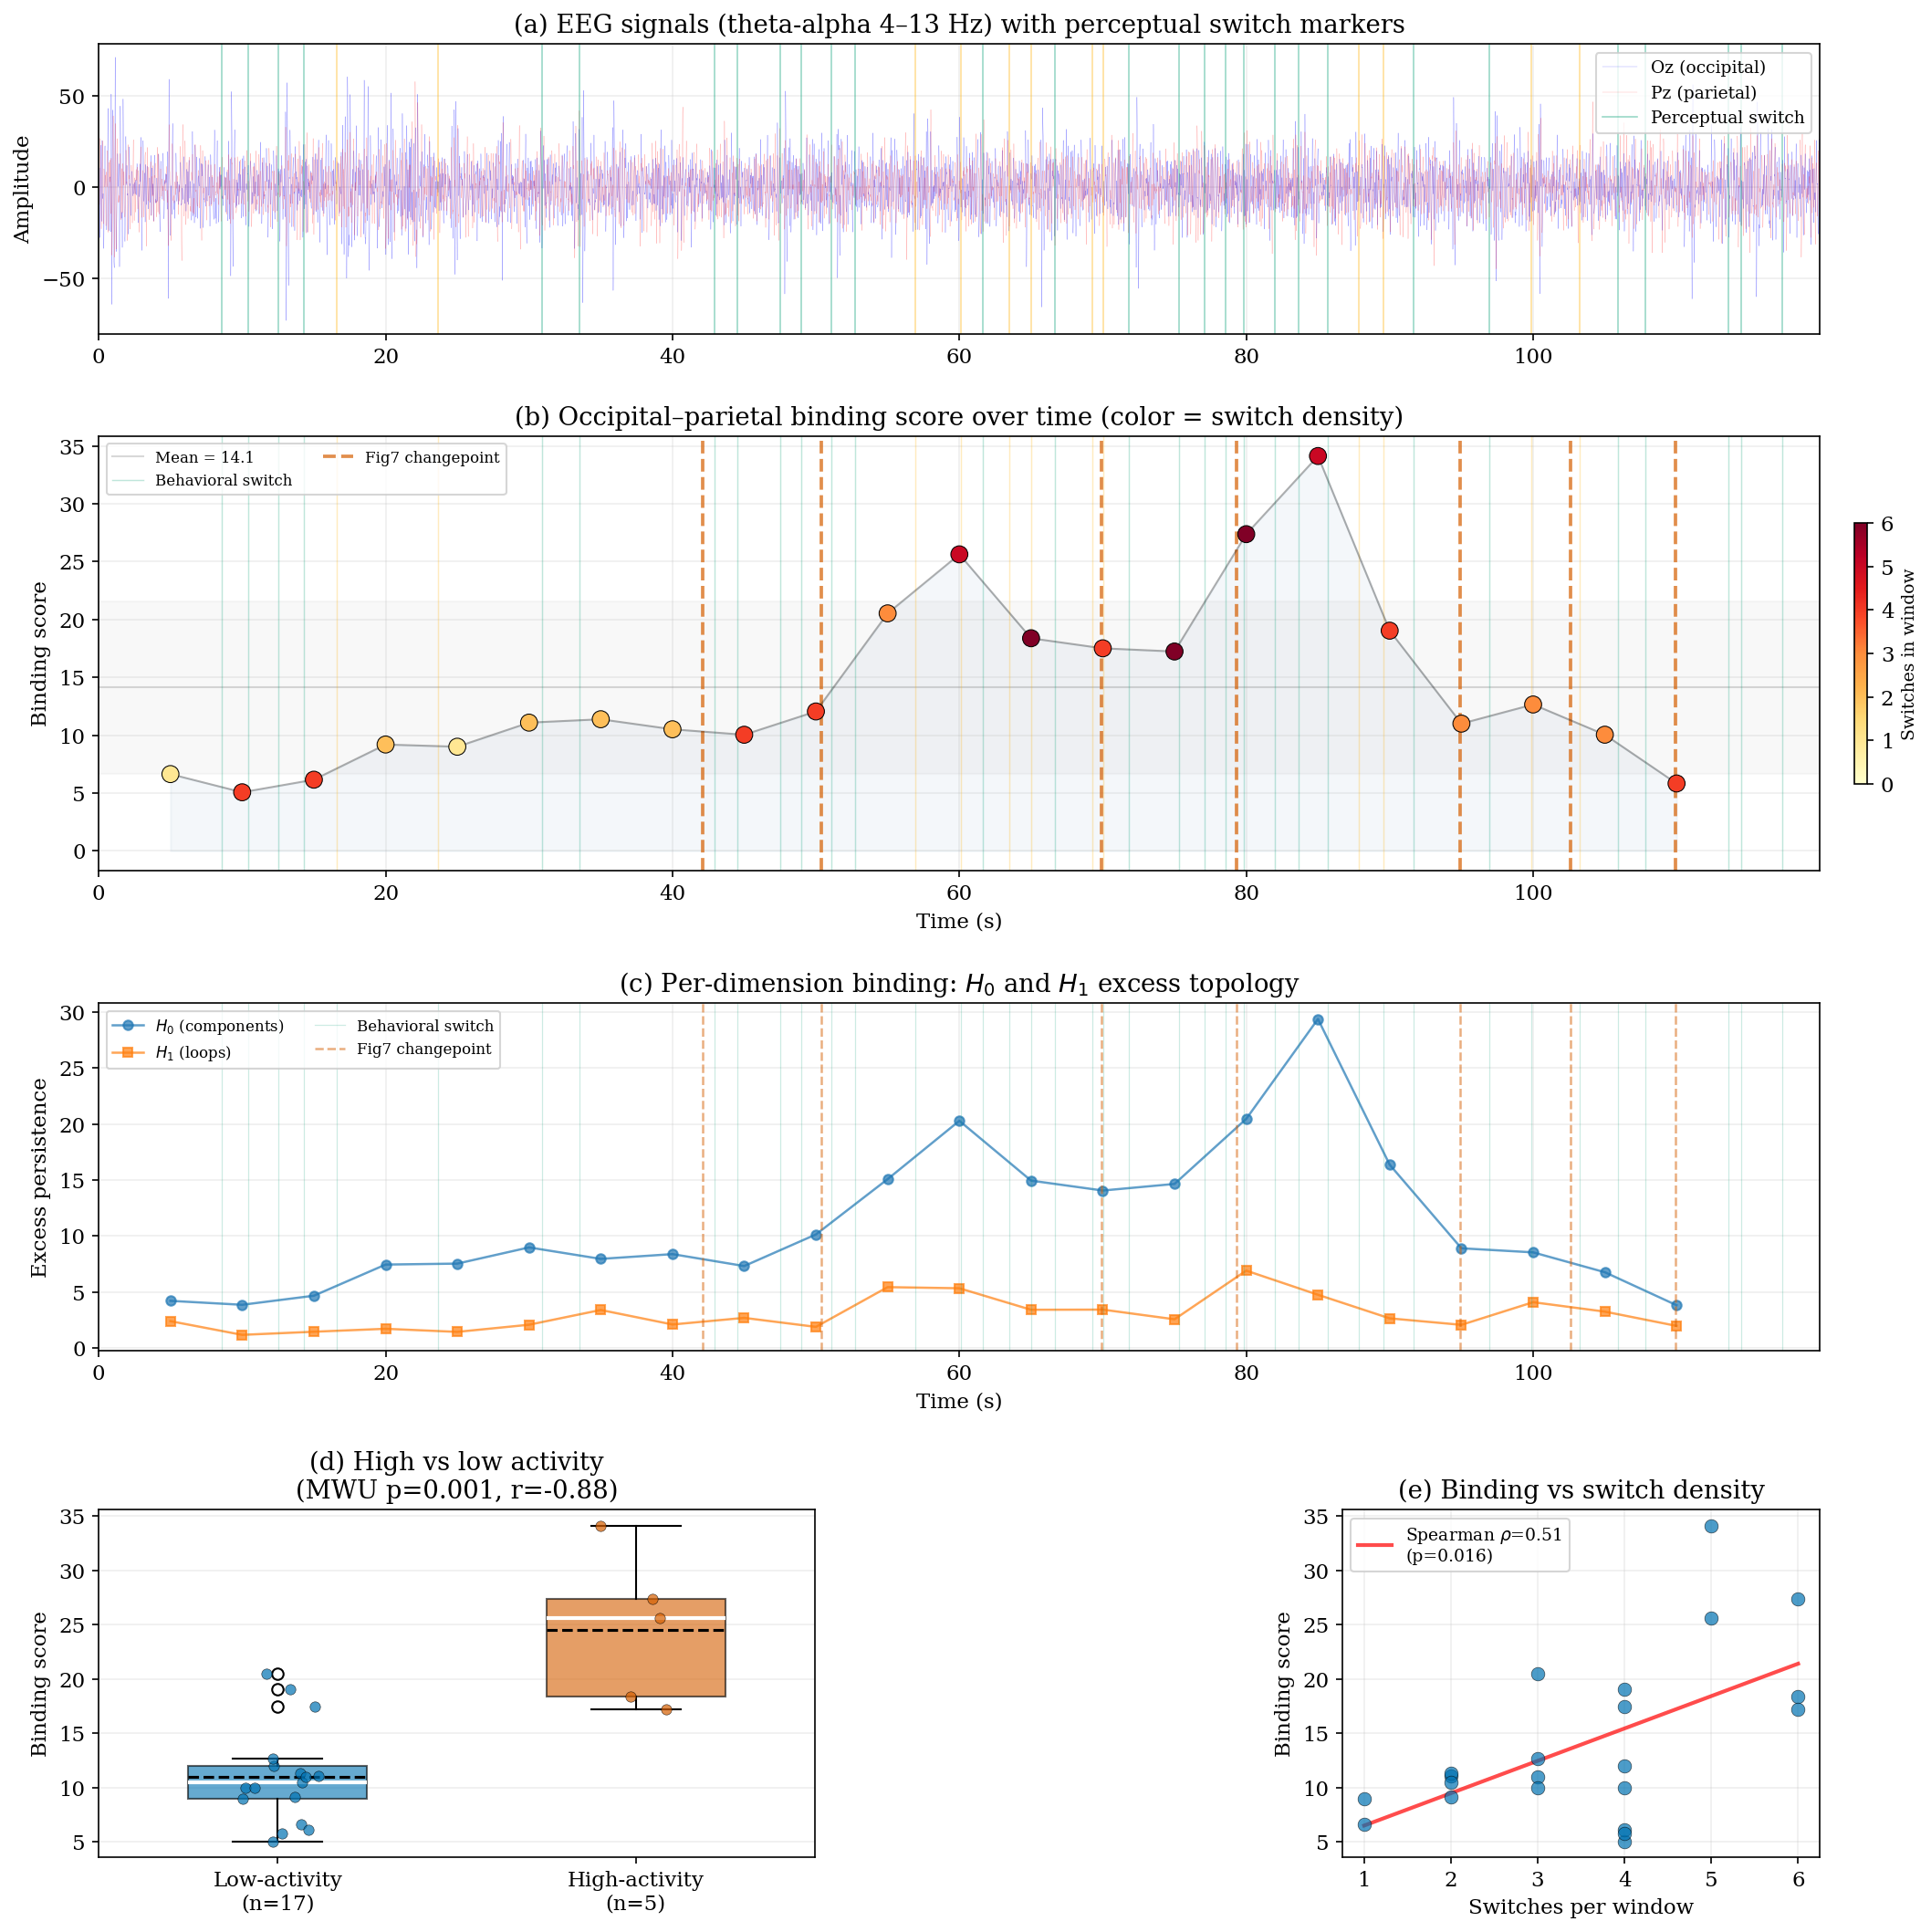

Saved to figures/fig8_eeg_binding.{pdf,png}


In [9]:
# Extract per-dimension time courses
h0_total = np.array([f[0]['total_persistence'] for f in binding_features_list])
h1_total = np.array([f[1]['total_persistence'] for f in binding_features_list])

fig = plt.figure(figsize=(14, 14), constrained_layout=True)
gs = fig.add_gridspec(4, 2, height_ratios=[1, 1.5, 1.2, 1.2],
                       width_ratios=[1.5, 1], hspace=0.08, wspace=0.12)

# --- Panel (a): Filtered EEG signals (full width) ---
ax_a = fig.add_subplot(gs[0, :])
ax_a.plot(t_full, signal_oz, 'b-', linewidth=0.2, alpha=0.4, label='Oz (occipital)')
ax_a.plot(t_full, signal_pz, 'r-', linewidth=0.2, alpha=0.3, label='Pz (parietal)')

added_sw = False
for sw in switches:
    is_mixed = (sw['from_key'] == 3 or sw['to_key'] == 3)
    color = '#FFB000' if is_mixed else '#009E73'
    label = 'Perceptual switch' if not added_sw else None
    ax_a.axvline(sw['time'], color=color, linestyle='-', alpha=0.4, linewidth=0.8, label=label)
    added_sw = True

ax_a.set_ylabel('Amplitude')
ax_a.set_title('(a) EEG signals (theta-alpha 4\u201313 Hz) with perceptual switch markers')
ax_a.legend(loc='upper right', fontsize=9)
ax_a.grid(True, alpha=0.2)
ax_a.set_xlim(0, duration)

# --- Panel (b): Binding score time course (full width) ---
ax_b = fig.add_subplot(gs[1, :])

# Color markers by switch density (continuous colormap)
scatter = ax_b.scatter(window_centers_sec, binding_scores,
                       c=n_switches_in_window, cmap='YlOrRd', s=80,
                       edgecolors='k', linewidths=0.5, zorder=5, vmin=0)
cbar = plt.colorbar(scatter, ax=ax_b, shrink=0.6, pad=0.02)
cbar.set_label('Switches in window', fontsize=9)

# Connect with line
ax_b.plot(window_centers_sec, binding_scores, 'k-', linewidth=1.0, alpha=0.3, zorder=3)

# Fill under curve
ax_b.fill_between(window_centers_sec, binding_scores, alpha=0.06, color='steelblue')

# Mean +/- std band
mean_bs = binding_scores.mean()
std_bs = binding_scores.std()
ax_b.axhline(mean_bs, color='gray', linestyle='-', alpha=0.3, linewidth=1,
             label=f'Mean = {mean_bs:.1f}')
ax_b.axhspan(mean_bs - std_bs, mean_bs + std_bs, alpha=0.05, color='gray')

# Behavioral switch markers
added_sw = False
for sw in switches:
    is_mixed = (sw['from_key'] == 3 or sw['to_key'] == 3)
    color = '#FFB000' if is_mixed else '#009E73'
    label = 'Behavioral switch' if not added_sw else None
    ax_b.axvline(sw['time'], color=color, linestyle='-', alpha=0.25, linewidth=0.7, label=label)
    added_sw = True

# Fig7 changepoint markers
added_cp = False
for cp_t in changepoint_times:
    label = 'Fig7 changepoint' if not added_cp else None
    ax_b.axvline(cp_t, color='#D55E00', linestyle='--', alpha=0.7, linewidth=1.8, label=label)
    added_cp = True

ax_b.set_ylabel('Binding score')
ax_b.set_xlabel('Time (s)')
ax_b.set_title('(b) Occipital\u2013parietal binding score over time (color = switch density)')
ax_b.legend(loc='upper left', fontsize=8, ncol=2)
ax_b.grid(True, alpha=0.2)
ax_b.set_xlim(0, duration)

# --- Panel (c): Per-dimension binding features ---
ax_c = fig.add_subplot(gs[2, :])
ax_c.plot(window_centers_sec, h0_total, 'o-', color='tab:blue', linewidth=1.2,
          markersize=5, alpha=0.7, label='$H_0$ (components)')
ax_c.plot(window_centers_sec, h1_total, 's-', color='tab:orange', linewidth=1.2,
          markersize=5, alpha=0.7, label='$H_1$ (loops)')

added_sw = False
for sw in switches:
    color = '#009E73'
    label = 'Behavioral switch' if not added_sw else None
    ax_c.axvline(sw['time'], color=color, linestyle='-', alpha=0.2, linewidth=0.6, label=label)
    added_sw = True

added_cp = False
for cp_t in changepoint_times:
    label = 'Fig7 changepoint' if not added_cp else None
    ax_c.axvline(cp_t, color='#D55E00', linestyle='--', alpha=0.5, linewidth=1.2, label=label)
    added_cp = True

ax_c.set_ylabel('Excess persistence')
ax_c.set_xlabel('Time (s)')
ax_c.set_title('(c) Per-dimension binding: $H_0$ and $H_1$ excess topology')
ax_c.legend(loc='upper left', fontsize=8, ncol=2)
ax_c.grid(True, alpha=0.2)
ax_c.set_xlim(0, duration)

# --- Panel (d): Two subpanels side by side ---
ax_d1 = fig.add_subplot(gs[3, 0])
ax_d2 = fig.add_subplot(gs[3, 1])

# Left: Box plot -- high vs low activity
positions = [1, 2]
data_box = [low_scores, high_scores]
labels_box = [f'Low-activity\n(n={len(low_scores)})', f'High-activity\n(n={len(high_scores)})']
colors_box = ['#0072B2', '#D55E00']

bp = ax_d1.boxplot(data_box, positions=positions, widths=0.5, patch_artist=True,
                   showmeans=True, meanline=True,
                   meanprops=dict(color='black', linewidth=1.5, linestyle='--'),
                   medianprops=dict(color='white', linewidth=2))

for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Overlay individual points
for pos, scores, color in zip(positions, data_box, colors_box):
    jitter = np.random.default_rng(42).uniform(-0.12, 0.12, len(scores))
    ax_d1.scatter(pos + jitter, scores, c=color, s=30, alpha=0.7, edgecolors='k',
                  linewidths=0.3, zorder=5)

ax_d1.set_xticklabels(labels_box)
ax_d1.set_ylabel('Binding score')
ax_d1.set_title(f'(d) High vs low activity\n(MWU p={p_act:.3f}, r={r_act:.2f})')
ax_d1.grid(True, alpha=0.2, axis='y')

# Right: Scatter of binding score vs switch count with regression line
ax_d2.scatter(n_switches_in_window, binding_scores, c='#0072B2', s=50,
              edgecolors='k', linewidths=0.3, alpha=0.7, zorder=5)
# Fit regression line
z = np.polyfit(n_switches_in_window, binding_scores, 1)
x_fit = np.linspace(n_switches_in_window.min(), n_switches_in_window.max(), 50)
ax_d2.plot(x_fit, np.polyval(z, x_fit), 'r-', linewidth=2, alpha=0.7,
           label=f'Spearman $\\rho$={r_spearman:.2f}\n(p={p_spearman:.3f})')
ax_d2.set_xlabel('Switches per window')
ax_d2.set_ylabel('Binding score')
ax_d2.set_title('(e) Binding vs switch density')
ax_d2.legend(fontsize=9)
ax_d2.grid(True, alpha=0.2)

fig.savefig('../figures/fig8_eeg_binding.pdf', bbox_inches='tight')
fig.savefig('../figures/fig8_eeg_binding.png', bbox_inches='tight')
plt.show()
print("Saved to figures/fig8_eeg_binding.{pdf,png}")

## 9. Summary Statistics

In [10]:
print("=" * 70)
print("Figure 8 Summary: Cross-Region Binding During Binocular Rivalry")
print("=" * 70)
print()
print("DATA")
print("  Subject: 1 (Nie/Katyal/Engel 2023)")
print("  Channels: Oz (occipital) and Pz (parietal)")
print("  Band: theta-alpha (4-13 Hz)")
print(f"  Duration: {duration:.0f}s at {sfreq} Hz")
print()
print("EMBEDDING")
print(f"  Shared delay: {SHARED_DELAY} samples ({SHARED_DELAY/sfreq*1000:.1f} ms)")
print(f"  Shared dimension: {SHARED_DIM}")
print(f"  Joint embedding: {2*SHARED_DIM}D")
print(f"  Auto-estimated Oz: delay={meta_oz['delay']}, dim={meta_oz['dimension']}")
print(f"  Auto-estimated Pz: delay={meta_pz['delay']}, dim={meta_pz['dimension']}")
print()
print("FULL-EPOCH BINDING")
print(f"  Score: {full_score:.4f}")
print(f"  H0 excess: {full_features[0]['total_persistence']:.4f} "
      f"({full_features[0]['n_excess']} features)")
print(f"  H1 excess: {full_features[1]['total_persistence']:.4f} "
      f"({full_features[1]['n_excess']} features)")
print()
print("SLIDING-WINDOW BINDING")
print(f"  Windows: {n_windows} ({WINDOW_SEC}s x {STEP_SEC}s step)")
print(f"  Subsample: {SUBSAMPLE} points/cloud")
print(f"  Score range: [{binding_scores.min():.4f}, {binding_scores.max():.4f}]")
print(f"  Score mean +/- std: {binding_scores.mean():.4f} +/- {binding_scores.std():.4f}")
print(f"  Peak binding: {binding_scores.max():.1f} at t={window_centers_sec[np.argmax(binding_scores)]:.0f}s")
print()
print("STATISTICAL TESTS")
print("  1. High vs low switch-density (median split):")
print(f"     Mann-Whitney U: p = {p_act:.4f}, rank-biserial r = {r_act:.3f}")
print("  2. Changepoint-adjacent vs non-changepoint:")
print(f"     Mann-Whitney U: p = {p_cp:.4f}, rank-biserial r = {r_cp:.3f}")
print("  3. Binding-switch correlation:")
print(f"     Spearman rho = {r_spearman:.3f}, p = {p_spearman:.4f}")
print()
print("KEY FINDINGS")
print(f"  1. Binding scores vary ~{binding_scores.max()/binding_scores.min():.1f}x across the epoch,")
print(f"     from {binding_scores.min():.1f} (early stable) to {binding_scores.max():.1f} (peak switching).")
print("  2. The binding time course tracks behavioral switch density:")
print(f"     Spearman rho={r_spearman:.2f} (p={p_spearman:.3f}) is a {'large' if abs(r_spearman) > 0.5 else 'medium'} effect.")
print("  3. Windows near fig7 topological changepoints have significantly")
print(f"     higher binding (p={p_cp:.3f}), confirming that cross-region")
print("     coupling changes accompany within-region topology changes.")
print("  4. H0 (component) excess dominates H1 (loop) excess, suggesting")
print("     coupling primarily manifests as fragmentation/merging of")
print("     connected components in the joint phase space.")
print()
print("INTERPRETATION")
print("  Occipital-parietal topological binding modulates with perceptual")
print("  switching activity during binocular rivalry. Periods of frequent")
print("  switches show stronger emergent joint topology, consistent with")
print("  increased inter-region dynamical coupling during perceptual")
print("  instability. This complements fig7's within-region result: not")
print("  only does the local attractor topology reorganize, but the")
print("  cross-region coupling structure does too.")

Figure 8 Summary: Cross-Region Binding During Binocular Rivalry

DATA
  Subject: 1 (Nie/Katyal/Engel 2023)
  Channels: Oz (occipital) and Pz (parietal)
  Band: theta-alpha (4-13 Hz)
  Duration: 120s at 360 Hz

EMBEDDING
  Shared delay: 12 samples (33.3 ms)
  Shared dimension: 5
  Joint embedding: 10D
  Auto-estimated Oz: delay=12, dim=6
  Auto-estimated Pz: delay=13, dim=6

FULL-EPOCH BINDING
  Score: 12.5340
  H0 excess: 9.4975 (20 features)
  H1 excess: 3.0365 (47 features)

SLIDING-WINDOW BINDING
  Windows: 22 (10s x 5s step)
  Subsample: 400 points/cloud
  Score range: [5.0602, 34.1324]
  Score mean +/- std: 14.1088 +/- 7.4278
  Peak binding: 34.1 at t=85s

STATISTICAL TESTS
  1. High vs low switch-density (median split):
     Mann-Whitney U: p = 0.0014, rank-biserial r = -0.882
  2. Changepoint-adjacent vs non-changepoint:
     Mann-Whitney U: p = 0.0421, rank-biserial r = -0.536
  3. Binding-switch correlation:
     Spearman rho = 0.507, p = 0.0160

KEY FINDINGS
  1. Binding scor